# 01 — EDA y Limpieza de Datos
**Problema:** Predecir si una persona en Bogotá tendrá un intento de suicidio vs ideación suicida.
**Dataset:** Conducta Suicida Bogotá — Datos Abiertos Bogotá (Secretaría Distrital de Salud)

In [8]:
import sys
sys.path.append('../src')  # permite importar desde la carpeta src/

import warnings
warnings.filterwarnings('ignore')  # suprimir advertencias de versiones de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos propios del proyecto
from preprocessing import load_raw, clean, TARGET_COL, BINARY_COLS
from plots import plot_eda_combined
from paths import ensure_results_dirs
from verification import verify_raw, print_verification_report

# Rutas de archivos
RAW_PATH       = '../data/raw/conducta_suicida_bogota.csv'
PROCESSED_PATH = '../data/processed/datos_limpios.csv'
EDA_PATH       = '../results/eda/'

ensure_results_dirs('../results')
sns.set_theme(style='whitegrid')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de datos

In [9]:
# Cargamos el CSV original con encoding latin-1 (caracteres especiales en español)
# y con detección automática del separador (el dataset usa ';')
df_raw = load_raw(RAW_PATH)
print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}')
df_raw.head()

Filas: 254,251 | Columnas: 19


,ano_notificacion,codigo_localidadresidencia,localidad_residencia,nombre_upz,ciclovital,clasificaciondelaconducta,sexo,edad,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
0,2023,15.0,Antonio Nariño,CIUDAD JARDIN,>60 Vejez,Intento de Suicidio,Hombre,71,3. Primaria incompleta,0,0,0,1,0,0,0,0,0,Ninguna
1,2022,4.0,San Cristóbal,LA GLORIA,>60 Vejez,Intento de Suicidio,Hombre,71,4. Primaria completa,1,0,1,0,0,0,0,0,0,Ninguna
2,2025,19.0,Ciudad Bolívar,LUCERO,>60 Vejez,Ideación suicida,Mujer,71,5. Secundaria incompleta,0,1,0,1,1,0,0,0,0,Ninguna
3,2023,18.0,Rafael Uribe Uribe,MARRUECOS,>60 Vejez,Ideación suicida,Hombre,71,3. Primaria incompleta,1,0,0,1,1,0,0,1,0,Ninguna
4,2017,13.0,Teusaquillo,QUINTA PAREDES,>60 Vejez,Ideación suicida,Mujer,71,10. Universidad completa,0,0,0,0,0,0,0,0,0,Otra


## 2. Inspección inicial

In [10]:
# Revisamos tipos de datos y estadísticas descriptivas para entender
# qué columnas son numéricas, cuáles categóricas y cuáles binarias (0/1)
print('Tipos de datos:')
print(df_raw.dtypes)
print('\nEstadísticas básicas:')
df_raw.describe(include='all')

Tipos de datos:
ano_notificacion                int64
codigo_localidadresidencia    float64
localidad_residencia              str
nombre_upz                        str
ciclovital                        str
clasificaciondelaconducta         str
sexo                              str
edad                            int64
niveleducativo                    str
enfermedades_dolorosas          int64
maltrato_sexual                 int64
muerte_familiar                 int64
conflicto_pareja                int64
problemas_economicos            int64
esc_educ                        int64
problemas_juridicos             int64
problemas_laborales             int64
suicidio_amigo                  int64
poblacion_diferencial             str
dtype: object

Estadísticas básicas:


,ano_notificacion,codigo_localidadresidencia,localidad_residencia,nombre_upz,ciclovital,clasificaciondelaconducta,sexo,edad,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,esc_educ,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
count,254251.000000,254093.000000,254251,254251,254251,254251,254251,254251.000000,254251,254251.000000,254251.000000,254251.000000,254251.000000,254251.000000,254251.000000,254251.000000,254251.000000,254251.000000,234158
unique,NaN,NaN,21,113,6,2,3,NaN,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10
top,NaN,NaN,Kennedy,UPZ Sin asignar,12  17 Adolescencia,Ideación suicida,Mujer,NaN,5. Secundaria incompleta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ninguna
freq,NaN,NaN,33807,10820,81731,184462,165998,NaN,88669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,129899
mean,2021.238579,9.794870,NaN,NaN,NaN,NaN,NaN,24.718455,NaN,0.063449,0.103736,0.095457,0.245049,0.188680,0.242418,0.012279,0.112688,0.018317,NaN
std,3.451909,5.067247,NaN,NaN,NaN,NaN,NaN,13.827359,NaN,0.243769,0.304918,0.293846,0.430117,0.391255,0.428547,0.110129,0.316211,0.134094,NaN
min,2012.000000,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2019.000000,7.000000,NaN,NaN,NaN,NaN,NaN,15.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,2022.000000,9.000000,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,2024.000000,12.000000,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


## 3. Valores nulos

In [11]:
# Identificamos cuántos valores nulos tiene cada columna y su porcentaje.
# Solo columnas con nulos — tabla clara para el informe (sin gráfica: escalas muy distintas).
nulls = df_raw.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df_raw) * 100).round(2)
null_df = pd.DataFrame({'nulos': nulls, '%': nulls_pct})
cols_con_nulos = null_df[null_df['nulos'] > 0].copy()

# Acción de limpieza planeada por columna (se aplica en clean())
estrategia = {
    'poblacion_diferencial': "Imputar con 'Ninguna'",
    'codigo_localidadresidencia': 'Eliminar (redundante con nombre de localidad)',
}
cols_con_nulos['estrategia_limpieza'] = [
    estrategia.get(str(col).lower().replace(' ', '_'), 'Revisar')
    for col in cols_con_nulos.index
]

print('Columnas con valores nulos:\n')
print(cols_con_nulos.to_string())
print(f'\nTotal columnas con al menos un nulo: {len(cols_con_nulos)}')

Columnas con valores nulos:

                            nulos     %                            estrategia_limpieza
poblacion_diferencial       20093  7.90                          Imputar con 'Ninguna'
codigo_localidadresidencia    158  0.06  Eliminar (redundante con nombre de localidad)

Total columnas con al menos un nulo: 2


## 4. Verificación de datos
Chequeos de calidad antes de la limpieza: duplicados, valores del target, outliers en edad y tipos de columnas.

=== Verificación de datos ===

Filas duplicadas exactas: 40,074 — se eliminarán en limpieza.
Valores de target: ['Ideación suicida', 'Intento de Suicidio'] — todos válidos.
Edad: min=1, max=102, outliers IQR=11,405 (no se eliminan; RF es robusto).

Columnas numéricas: 12
Columnas categóricas/texto: 7


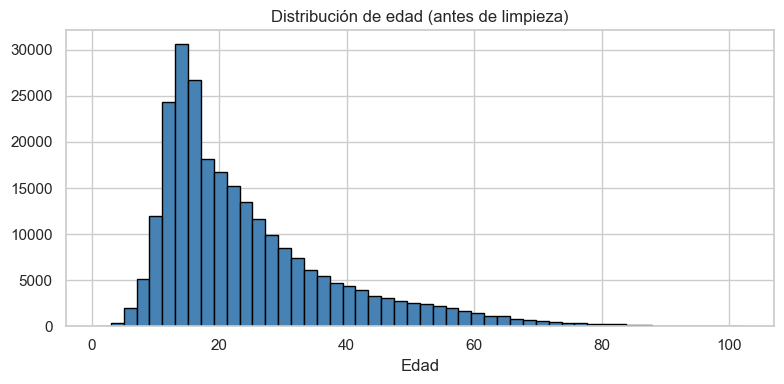

In [12]:
# Verificación explícita (requisito del enunciado)
verif = verify_raw(df_raw)
print_verification_report(verif)

# Visualizar distribución de edad y posibles outliers
if 'edad' in df_raw.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    df_raw['edad'].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Distribución de edad (antes de limpieza)')
    ax.set_xlabel('Edad')
    plt.tight_layout()
    plt.savefig(EDA_PATH + 'distribucion_edad.png', dpi=150)
    plt.show()

## 5. EDA Combinado — 6 subplots

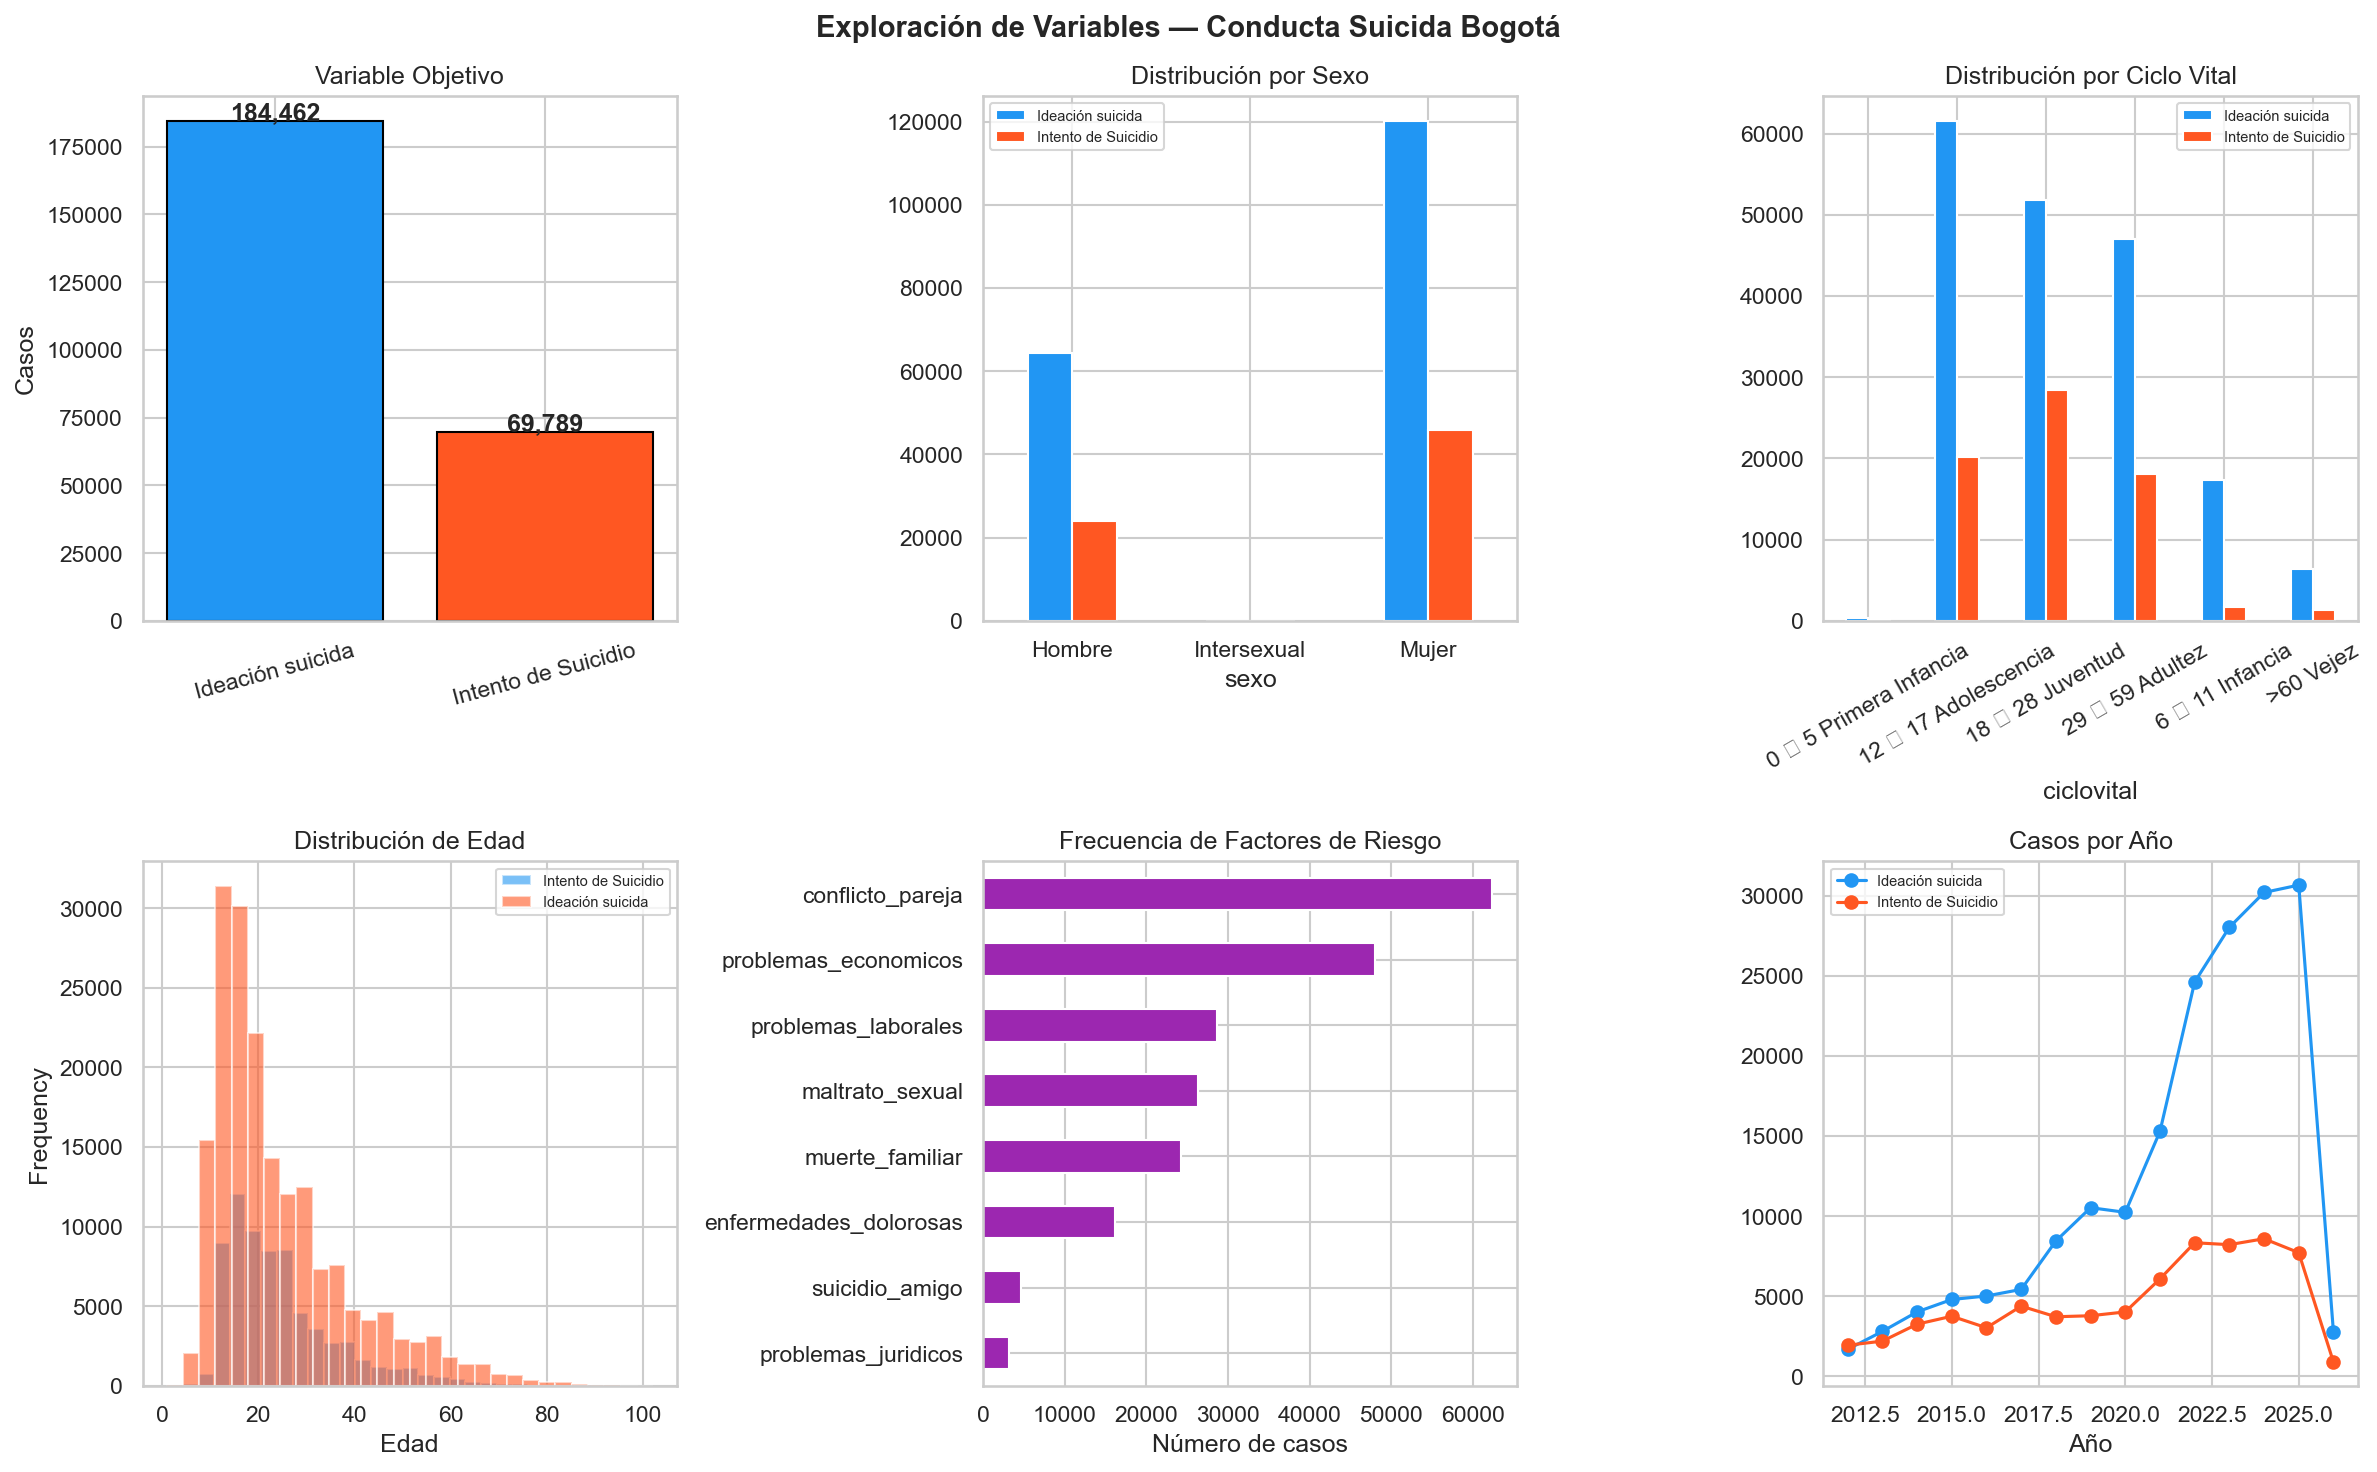

In [13]:
# Figura combinada con 6 subplots para entender la distribución del dataset:
#   1. Balance de clases (target) — importante para detectar desbalanceo
#   2. Distribución por sexo separada por clase — ¿hay diferencia de género?
#   3. Ciclo vital por clase — ¿qué grupos etarios tienen más intentos?
#   4. Histograma de edad por clase — distribución continua de la edad
#   5. Frecuencia de factores de riesgo — cuáles son los más comunes
#   6. Evolución temporal — crecimiento de casos 2012-2026
plot_eda_combined(df_raw, TARGET_COL, EDA_PATH + 'eda_combinado.png')

from IPython.display import Image
Image(EDA_PATH + 'eda_combinado.png')

## 6. Limpieza y exportación

## 7. Gráficas adicionales

In [14]:
# Aplicamos la limpieza completa:
#   - Elimina columnas redundantes (código localidad, nombre UPZ, esc_educ)
#   - Estandariza niveleducativo (unifica variantes de texto)
#   - Rellena NaN en factores binarios con 0
#   - Rellena poblacion_diferencial con 'Ninguna'
# Los NaN restantes en columnas numéricas se imputan con mediana en el paso de encoding
n_dup_antes = df_raw.duplicated().sum()
df_clean = clean(df_raw)
print(f'Filas originales:     {df_raw.shape[0]:,}')
print(f'Duplicados eliminados: {n_dup_antes:,}')
print(f'Filas tras limpieza:  {df_clean.shape[0]:,}')
print(f'Columnas eliminadas:  codigo_localidadresidencia, nombre_upz, esc_educ')
print(f'Nulos restantes:      {df_clean.isnull().sum().sum()}')
print(f'\nNiveles educativos estandarizados: {df_clean["niveleducativo"].nunique()}')
print(f'Balance de clases:\n{df_clean[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + "%"}')

# Guardamos el CSV limpio — los notebooks 02 y 03 lo leen directamente
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f'\n✅ Datos limpios guardados en {PROCESSED_PATH}')
df_clean.head()

Filas originales:     254,251
Duplicados eliminados: 40,074
Filas tras limpieza:  214,177
Columnas eliminadas:  codigo_localidadresidencia, nombre_upz, esc_educ
Nulos restantes:      0

Niveles educativos estandarizados: 13
Balance de clases:
clasificaciondelaconducta
Ideación suicida       70.1%
Intento de Suicidio    29.9%
Name: proportion, dtype: str

✅ Datos limpios guardados en ../data/processed/datos_limpios.csv


,ano_notificacion,localidad_residencia,ciclovital,clasificaciondelaconducta,sexo,edad,niveleducativo,enfermedades_dolorosas,maltrato_sexual,muerte_familiar,conflicto_pareja,problemas_economicos,problemas_juridicos,problemas_laborales,suicidio_amigo,poblacion_diferencial
0,2023,Antonio Nariño,>60 Vejez,Intento de Suicidio,Hombre,71,03_Primaria_inc,0,0,0,1,0,0,0,0,Ninguna
1,2022,San Cristóbal,>60 Vejez,Intento de Suicidio,Hombre,71,04_Primaria_comp,1,0,1,0,0,0,0,0,Ninguna
2,2025,Ciudad Bolívar,>60 Vejez,Ideación suicida,Mujer,71,05_Secundaria_inc,0,1,0,1,1,0,0,0,Ninguna
3,2023,Rafael Uribe Uribe,>60 Vejez,Ideación suicida,Hombre,71,03_Primaria_inc,1,0,0,1,1,0,1,0,Ninguna
4,2017,Teusaquillo,>60 Vejez,Ideación suicida,Mujer,71,10_Univ_comp,0,0,0,0,0,0,0,0,Otra


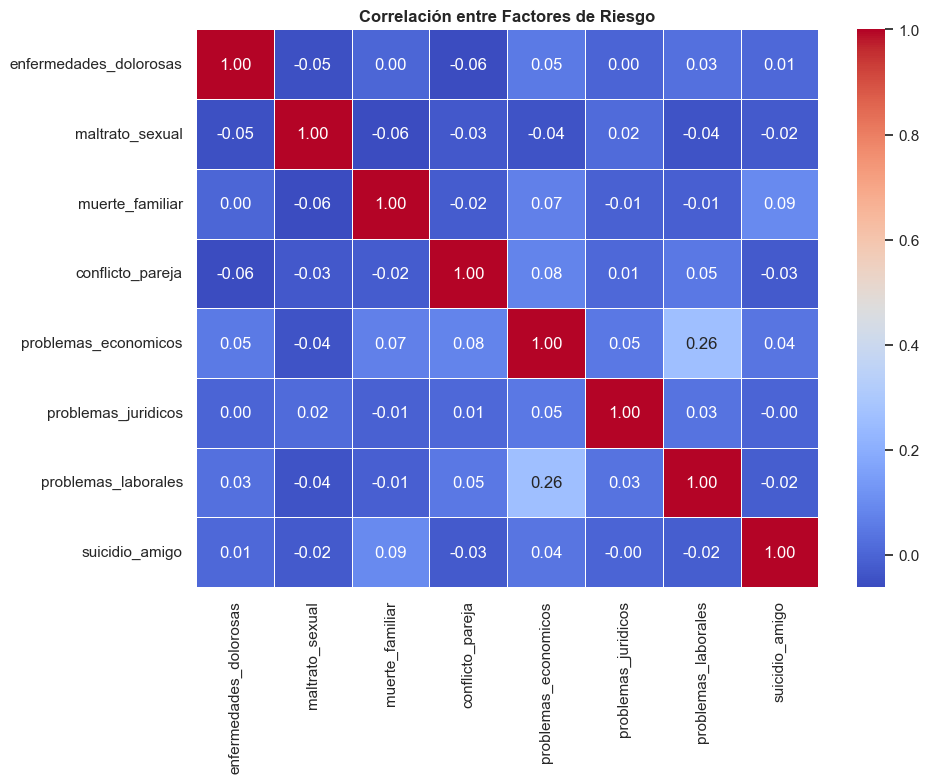

In [15]:
# Heatmap sobre datos limpios — así refleja las correlaciones reales sin ruido de NaN.
# Si dos factores están correlacionados, tienden a aparecer juntos en los casos.
# Útil para identificar perfiles de riesgo (ej: conflicto de pareja + problemas económicos).
existing_binary = [c for c in BINARY_COLS if c in df_clean.columns]
if existing_binary:
    corr = df_clean[existing_binary].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
    ax.set_title('Correlación entre Factores de Riesgo', fontweight='bold')
    plt.tight_layout()
    plt.savefig(EDA_PATH + 'heatmap_factores.png', dpi=150)
    plt.show()